In [39]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when

In [40]:
spark = SparkSession.builder \
    .appName("SECOP_RegresionLogistica") \
    .master("spark://spark-master:7077") \
    .getOrCreate()

df = spark.read.parquet("/opt/spark-data/processed/secop_features.parquet")
print(f"Registros: {df.count():,}")
print("Columnas:", df.columns)

Registros: 100,000
Columnas: ['referencia_del_contrato', 'nit_entidad', 'nombre_entidad', 'departamento', 'ciudad', 'tipo_de_contrato', 'valor_del_contrato', 'fecha_de_firma', 'duraci_n_del_contrato', 'proveedor_adjudicado', 'estado_contrato', 'year', 'month', 'label', 'fecha_de_firma_parsed', 'anio', 'mes', 'tipo_de_contrato_idx', 'departamento_idx', 'ciudad_idx', 'tipo_de_contrato_vec', 'departamento_vec', 'ciudad_vec', 'features_raw']


In [41]:
from pyspark.sql.functions import col

df = spark.read.parquet("/opt/spark-data/processed/secop_features.parquet")
print("Columnas:", df.columns)

# Asegurar columnas estándar
if "features" not in df.columns and "features_raw" in df.columns:
    df = df.withColumnRenamed("features_raw", "features")

# label ya existe (según tu error), pero por si acaso:
if "label" not in df.columns and "valor_del_contrato_num" in df.columns:
    df = df.withColumnRenamed("valor_del_contrato_num", "label")

# Ahora sí, filtra nulos
df = df.filter(col("label").isNotNull()).filter(col("features").isNotNull())
print(f"Registros limpios: {df.count():,}")

Columnas: ['referencia_del_contrato', 'nit_entidad', 'nombre_entidad', 'departamento', 'ciudad', 'tipo_de_contrato', 'valor_del_contrato', 'fecha_de_firma', 'duraci_n_del_contrato', 'proveedor_adjudicado', 'estado_contrato', 'year', 'month', 'label', 'fecha_de_firma_parsed', 'anio', 'mes', 'tipo_de_contrato_idx', 'departamento_idx', 'ciudad_idx', 'tipo_de_contrato_vec', 'departamento_vec', 'ciudad_vec', 'features_raw']


Registros limpios: 100,000


In [42]:
# Percentil 90 del valor del contrato 
p90 = df.approxQuantile("label", [0.90], 0.01)[0]
print("Percentil 90 (label):", p90)

df = df.withColumn(
    "riesgo",
    when(col("label") > p90, 1).otherwise(0)
)

# Justificación:
# Criterio elegido: riesgo = 1 si valor > percentil 90.
# Razón: los contratos de mayor cuantía suelen tener mayor complejidad, mayor exposición financiera
# y potencialmente mayor riesgo operativo/administrativo (baseline razonable sin variable real de incumplimiento)

Percentil 90 (label): 94640000.0


Alto riesgo (1) = contratos con valor > 94,640,000 COP Bajo riesgo (0) = contratos con valor ≤ 94,640,000 COP

In [43]:
from pyspark.sql.functions import col, when

# 1) Calcular percentil 90 usando la columna label 
p90 = df.approxQuantile("label", [0.90], 0.01)[0]
print(f"Percentil 90 (label): {p90:,.2f}")

# 2) Crear la variable objetivo binaria "riesgo"
# Alto riesgo (1) si el valor del contrato es mayor al percentil 90
df = df.withColumn(
    "riesgo",
    when(col("label") > p90, 1).otherwise(0)
)

# Justificación:
# Criterio elegido: riesgo = 1 si label (valor del contrato) > percentil 90; en caso contrario 0.
# Razón: Ante la ausencia de una variable real de incumplimiento, se usa el valor del contrato como proxy:
# contratos de mayor cuantía suelen implicar mayor complejidad administrativa/técnica y mayor exposición financiera,
# por lo que son razonables de considerar como "mayor riesgo" para fines de clasificación.


Percentil 90 (label): 94,640,000.00


Justificación:
Criterio elegido: riesgo = 1 si label (valor del contrato) > percentil 90; en caso contrario 0.
Razón: Ante la ausencia de una variable real de incumplimiento, se usa el valor del contrato como proxy:
contratos de mayor cuantía suelen implicar mayor complejidad administrativa/técnica y mayor exposición financiera,
por lo que son razonables de considerar como "mayor riesgo" para fines de clasificación.

In [45]:
# ## RETO 2: Balance de Clases
print("\n=== DISTRIBUCIÓN DE CLASES ===")
df.groupBy("riesgo").count().show()

total = df.count()
clase_0 = df.filter(col("riesgo") == 0).count()
clase_1 = df.filter(col("riesgo") == 1).count()

print(f"Clase 0 (Bajo riesgo): {clase_0:,} ({clase_0/total*100:.1f}%)")
print(f"Clase 1 (Alto riesgo): {clase_1:,} ({clase_1/total*100:.1f}%)")




=== DISTRIBUCIÓN DE CLASES ===
+------+-----+
|riesgo|count|
+------+-----+
|     1|10945|
|     0|89055|
+------+-----+

Clase 0 (Bajo riesgo): 89,055 (89.1%)
Clase 1 (Alto riesgo): 10,945 (10.9%)


Respuestas:
¿Está balanceado? No. Por construcción con percentil 90, queda ~90% clase 0 y ~10% clase 1.

Si NO, ¿qué harías?
- Usar métricas apropiadas (AUC-ROC, F1 y Recall de la clase 1), no solo accuracy.
- Ajustar el threshold (< 0.5, por ejemplo 0.3) para mejorar el recall de alto riesgo.
- (Opcional) usar weightCol para penalizar más la clase minoritaria durante el entrenamiento.

Tu decisión:
Voy a priorizar AUC-ROC y métricas de clase 1, y ajustaré el threshold para aumentar la detección de alto riesgo.

In [46]:
# ## PASO 1: Preparar Datos
df_binary = df.select(
    col("riesgo").cast("int").alias("label"),
    col("features")
)

train, test = df_binary.randomSplit([0.7, 0.3], seed=42)

print(f"Train: {train.count():,}")
print(f"Test: {test.count():,}")


Train: 70,007
Test: 29,993


# ## RETO 3: Entender la Regresión Logística
La regresión logística se diferencia de la regresión lineal porque:
- A) Predice probabilidades entre 0 y 1: el modelo estima P(clase=1 | features)
- B) Usa función sigmoide (logística): transforma una combinación lineal de las features en una probabilidad acotada entre 0 y 1
- C) Es para clasificación: la salida final es una clase (0/1) según un threshold, no un valor continuo como en regresión lineal

En resumen, la regresión lineal predice montos/valores continuos, mientras que la logística predice la probabilidad de pertenecer a una clase (por ejemplo “alto riesgo”)

In [47]:
# ## RETO 4: Configurar el Modelo

from pyspark.ml.classification import LogisticRegression

lr_classifier = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=200,        # Más iteraciones para asegurar convergencia
    regParam=0.1,       # Sí: regularización L2 para mejorar generalización
    elasticNetParam=0.0,# 0.0 = L2 (Ridge). Estable y buen baseline
    threshold=0.3       # Más bajo que 0.5 para aumentar el recall de la clase 1 (alto riesgo)
)

print("✓ Clasificador configurado")
print(f"  maxIter: {lr_classifier.getMaxIter()}")
print(f"  regParam: {lr_classifier.getRegParam()}")
print(f"  threshold: {lr_classifier.getThreshold()}")

# Entrenar modelo
print("\nEntrenando clasificador...")
lr_model = lr_classifier.fit(train)
print("✓ Modelo entrenado")


✓ Clasificador configurado
  maxIter: 200
  regParam: 0.1
  threshold: 0.3

Entrenando clasificador...


✓ Modelo entrenado


Respuesta:
Usaría un threshold menor a 0.5, por ejemplo 0.3.
Justificación: con un dataset desbalanceado (90% clase 0, 10% clase 1), el threshold=0.5 tiende a favorecer la clase mayoritaria y reduce mucho el recall de la clase 1.
Al bajar el threshold aumentamos la detección de contratos de alto riesgo (recall),aceptando que puede subir la cantidad de falsos positivos


In [48]:
# ## PASO 2: Predicciones
predictions = lr_model.transform(test)
predictions.select("label", "prediction", "probability").show(10, truncate=False)


+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|
+-----+----------+----------------------------------------+
only showing top 10 rows



In [49]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

predictions2 = predictions.withColumn("prob_arr", vector_to_array(col("probability"))) \
                          .withColumn("p1", col("prob_arr")[1])


In [50]:
dudosos = predictions2.filter((col("p1") > 0.4) & (col("p1") < 0.6))

print("Casos dudosos:", dudosos.count())
dudosos.select("label", "prediction", "probability", "p1").show(10, truncate=False)



Casos dudosos: 141
+-----+----------+----------------------------------------+-------------------+
|label|prediction|probability                             |p1                 |
+-----+----------+----------------------------------------+-------------------+
|0    |1.0       |[0.5952503335239063,0.4047496664760937] |0.4047496664760937 |
|0    |1.0       |[0.4129101432791495,0.5870898567208505] |0.5870898567208505 |
|0    |1.0       |[0.4268570045241403,0.5731429954758597] |0.5731429954758597 |
|0    |1.0       |[0.4268570045241403,0.5731429954758597] |0.5731429954758597 |
|0    |1.0       |[0.4268570045241403,0.5731429954758597] |0.5731429954758597 |
|0    |1.0       |[0.4268570045241403,0.5731429954758597] |0.5731429954758597 |
|0    |1.0       |[0.4268570045241403,0.5731429954758597] |0.5731429954758597 |
|0    |1.0       |[0.4268570045241403,0.5731429954758597] |0.5731429954758597 |
|0    |1.0       |[0.5337698630153281,0.46623013698467186]|0.46623013698467186|
|0    |1.0       |[0.

In [51]:
print(predictions.columns)
predictions.select("label", "prediction", "probability", "rawPrediction").show(5, truncate=False)


['label', 'features', 'rawPrediction', 'probability', 'prediction']
+-----+----------+----------------------------------------+----------------------------------------+
|label|prediction|probability                             |rawPrediction                           |
+-----+----------+----------------------------------------+----------------------------------------+
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|[1.4528578763629159,-1.4528578763629159]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|[1.4528578763629159,-1.4528578763629159]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|[1.4528578763629159,-1.4528578763629159]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|[1.4528578763629159,-1.4528578763629159]|
|0    |0.0       |[0.8104378743161013,0.18956212568389874]|[1.4528578763629159,-1.4528578763629159]|
+-----+----------+----------------------------------------+----------------------------------------+
only showing top 5 rows

In [52]:
# ## RETO 6: Evaluación con Múltiples Métricas
# AUC-ROC (mide capacidad de separación entre clases, 0.5=azar, 1.0=perfecto)
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = evaluator_auc.evaluate(predictions)

# Métricas "weighted" 
evaluator_multi = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "accuracy"})
precision_w = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "weightedPrecision"})
recall_w = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "weightedRecall"})
f1_w = evaluator_multi.evaluate(predictions, {evaluator_multi.metricName: "f1"})

print("\n" + "="*60)
print("MÉTRICAS DE CLASIFICACIÓN (WEIGHTED)")
print("="*60)
print(f"AUC-ROC:   {auc:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision_w:.4f}")
print(f"Recall:    {recall_w:.4f}")
print(f"F1-Score:  {f1_w:.4f}")
print("="*60)

# ✅ Métricas específicas para la clase 1 (alto riesgo)
TP = predictions.filter((col("label")==1) & (col("prediction")==1)).count()
TN = predictions.filter((col("label")==0) & (col("prediction")==0)).count()
FP = predictions.filter((col("label")==0) & (col("prediction")==1)).count()
FN = predictions.filter((col("label")==1) & (col("prediction")==0)).count()

precision_1 = TP/(TP+FP) if (TP+FP)>0 else 0.0
recall_1 = TP/(TP+FN) if (TP+FN)>0 else 0.0
f1_1 = (2*precision_1*recall_1/(precision_1+recall_1)) if (precision_1+recall_1)>0 else 0.0

print("\n" + "="*60)
print("MÉTRICAS CLASE 1 (ALTO RIESGO)")
print("="*60)
print(f"TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print(f"Precision clase 1: {precision_1:.4f}")
print(f"Recall clase 1:    {recall_1:.4f}")
print(f"F1 clase 1:        {f1_1:.4f}")
print("="*60)


MÉTRICAS DE CLASIFICACIÓN (WEIGHTED)
AUC-ROC:   0.7976
Accuracy:  0.8890
Precision: 0.8574
Recall:    0.8890
F1-Score:  0.8475

MÉTRICAS CLASE 1 (ALTO RIESGO)
TP=215, FP=157, FN=3171, TN=26450
Precision clase 1: 0.5780
Recall clase 1:    0.0635
F1 clase 1:        0.1144


Respuesta:
¿Es bueno un AUC de 0.75?
Sí. Un AUC≈0.75 se considera "bueno" porque el modelo discrimina mejor que el azar (0.5)
y separa razonablemente las clases. En datasets desbalanceados, AUC es más confiable que accuracy.
Aun así, se debe complementar con precision/recall de la clase 1 y ajustar threshold si se quiere detectar más casos de alto riesgo.

In [32]:
# RETO 7: Matriz de Confusión + interpretación

from pyspark.sql.functions import col

print("\n=== MATRIZ DE CONFUSIÓN ===")
confusion_matrix = predictions.groupBy("label", "prediction").count()
confusion_matrix.orderBy("label", "prediction").show()

# Calcular manualmente TP, TN, FP, FN
TP = predictions.filter((col("label") == 1) & (col("prediction") == 1)).count()
TN = predictions.filter((col("label") == 0) & (col("prediction") == 0)).count()
FP = predictions.filter((col("label") == 0) & (col("prediction") == 1)).count()
FN = predictions.filter((col("label") == 1) & (col("prediction") == 0)).count()

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")


=== MATRIZ DE CONFUSIÓN ===
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|26450|
|    0|       1.0|  157|
|    1|       0.0| 3171|
|    1|       1.0|  215|
+-----+----------+-----+

TP=215, TN=26450, FP=157, FN=3171


Respuesta:

¿Qué es peor en ESTE problema?
- Falso Positivo (predecir alto riesgo cuando es bajo):
Consecuencia: se activan revisiones/controles adicionales innecesarios (más tiempo y costo operativo), se pueden retrasar aprobaciones o seguimiento de contratos que en realidad eran de bajo riesgo.
Es una “falsa alarma” y normalmente es manejable.

- Falso Negativo (predecir bajo riesgo cuando es alto):
Consecuencia: se deja pasar un contrato realmente de alto riesgo sin monitoreo ni controles, aumentando la probabilidad de problemas en ejecución, incumplimientos, sobrecostos o fallas administrativas.
El impacto potencial es mayor porque es un “miss crítico”.

Conclusión: para este caso suele ser peor un Falso Negativo (FN), por eso se justifica bajar el threshold para aumentar el recall de la clase 1 (alto riesgo).

Muestra usada para ROC: 3,041 registros
✅ Curva ROC guardada en: /opt/spark-data/processed/roc_curve.png


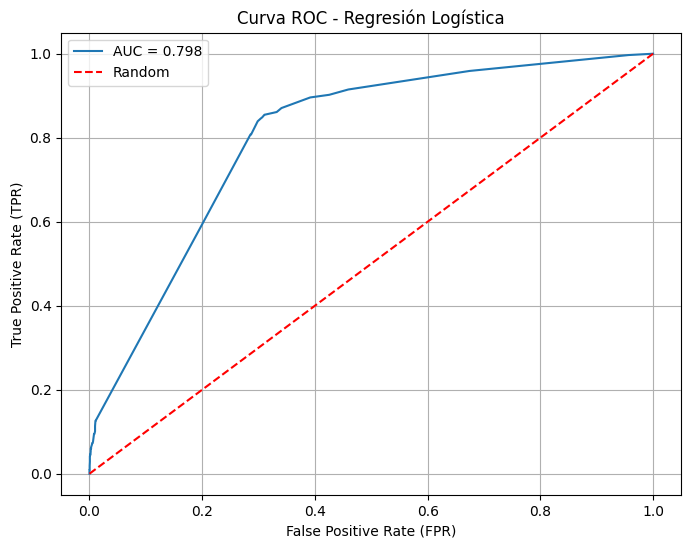

In [36]:
# ## RETO BONUS 2: Curva ROC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# 1) Extraer probabilidad de la clase 1 (p1) desde el vector probability
pred_prob = predictions.withColumn("p1", vector_to_array(col("probability"))[1]) \
                      .select("label", "p1")

# 2) Muestreo (recomendado) para no usar demasiada RAM
# Ajusta sample_frac si tu PC aguanta más (ej. 0.2). Con 0.1 suele ir bien.
sample_frac = 0.1
prob_df = pred_prob.sample(withReplacement=False, fraction=sample_frac, seed=42).toPandas()

probs = prob_df["p1"].values
labels = prob_df["label"].values.astype(int)

print(f"Muestra usada para ROC: {len(prob_df):,} registros")

# 3) Calcular TPR y FPR para diferentes thresholds
thresholds_roc = np.linspace(0, 1, 100)
tpr_list = []
fpr_list = []

for t in thresholds_roc:
    y_pred = (probs >= t).astype(int)

    tp = np.sum((y_pred == 1) & (labels == 1))
    fp = np.sum((y_pred == 1) & (labels == 0))
    tn = np.sum((y_pred == 0) & (labels == 0))
    fn = np.sum((y_pred == 0) & (labels == 1))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    tpr_list.append(tpr)
    fpr_list.append(fpr)

# 4) Graficar ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_list, tpr_list, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.grid(True)

# Guardar figura
out_path = "/opt/spark-data/processed/roc_curve.png"
plt.savefig(out_path)
print(f"✅ Curva ROC guardada en: {out_path}")


1. ¿Cuándo usarías regresión logística vs árboles de decisión?
Respuesta:
Utilizariamos regresión logística cuando:
- Quiero un modelo simple, rápido e interpretable (coeficientes que indican dirección/impacto).
- La relación entre features y la clase puede aproximarse bien con una frontera lineal.
- Necesito probabilidades calibradas de clase (P(clase=1)).
Utilizariamos árboles de decisión (o Random Forest ) cuando:
- Hay relaciones no lineales e interacciones complejas entre variables.
- Quiero capturar reglas tipo “si-entonces” y manejar naturalmente outliers.
- Busco mejor performance predictiva sin necesidad de tanta ingeniería de variables (aunque con más riesgo de overfitting).

2. ¿Qué significa un AUC de 0.5?
Respuesta:
Un AUC = 0.5 significa que el modelo no discrimina mejor que el azar. es decir que no es capaz de diferenciar o separar entre clases distintas. No separa positivos de negativos.

3. ¿Cómo manejarías un dataset con 99% clase 0 y 1% clase 1?
Respuesta:
- No usaría accuracy como métrica principal; priorizaría AUC-ROC/PR-AUC, Recall, Precision y F1 de la clase 1.
- Ajustaría el threshold para aumentar el recall de la clase minoritaria.
- Aplicaría técnicas de manejo de desbalance:
* class weights (weightCol en Spark) para penalizar más errores en la clase 1,
* oversampling de la clase 1 o undersampling de la clase 0 (con cuidado),
* y/o validación estratificada.
- También evaluaría modelos más robustos (árboles) y feature engineering.

4. ¿Por qué accuracy puede ser engañoso en clasificación desbalanceada?
Respuesta:
Porque un modelo puede obtener accuracy muy alta prediciendo siempre la clase mayoritaria.
Por ejemplo, con 99% clase 0, un modelo que siempre predice 0 tendría 99% accuracy, pero recall de la clase 1 sería 0% (no detecta ningún caso importante).

In [54]:
# %%
# Guardar modelo
model_path = "/opt/spark-data/processed/logistic_regression_model"
lr_model.write().overwrite().save(model_path)
print(f"\n✓ Modelo guardado en: {model_path}")


✓ Modelo guardado en: /opt/spark-data/processed/logistic_regression_model


In [55]:
# %%
print("\n" + "="*60)
print("RESUMEN CLASIFICACIÓN")
print("="*60)
print(f"✓ Criterio de riesgo definido")
print(f"✓ Modelo entrenado")
print(f"✓ AUC-ROC: {auc:.4f}")
print(f"✓ F1-Score: {f1:.4f}")
print(f"✓ Próximo paso: Regularización (notebook 07)")
print("="*60)

# %%
spark.stop()


RESUMEN CLASIFICACIÓN
✓ Criterio de riesgo definido
✓ Modelo entrenado
✓ AUC-ROC: 0.7976
✓ F1-Score: 0.8475
✓ Próximo paso: Regularización (notebook 07)
